In [1]:
from resources.imports import *

from resources.lattices import geometry, pStrainProperties, effProperties
from resources.calculations import get_ductileData, get_fractureData, calcUT, calcFT

In [4]:
LAT = "hex"
MODEL = "ductile"
l = 0.01  # m
nnx = 20
rD = 0.2

dis = 'per'
nSim = '1'

validation = False
psc = False

#os.chdir(r"C:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\data\Ti\tri")
os.chdir(r"C:\Users\exy053\Documents\analysis")

if validation:
    os.chdir(r"C:\Users\exy053\Documents\validation\\"+str(int(l*1000))+'\\'+str(rD))
    dis, nSim = 'per', '1'
elif psc:
    os.chdir(r"C:\Users\exy053\Documents\PerSizeConv4\\"+str(int(l*1000)))
    dis, nSim = 'per', '1'

In [11]:
append = True
appendReset = True
if appendReset:
    UTsave, FTsave = [], []

In [6]:
geom = geometry(LAT, l, nnx, FTcalc=True)

E = 123000e6  ## Pa
v = 0.3
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(LAT, E_pStrain, rD)

In [7]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Ductile-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    UTdf = get_ductileData(CSVout, crit=0.25)
    print(len(UTdf))

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Fracture-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    FTdf = get_fractureData(CSVout)
    print(len(FTdf))

202


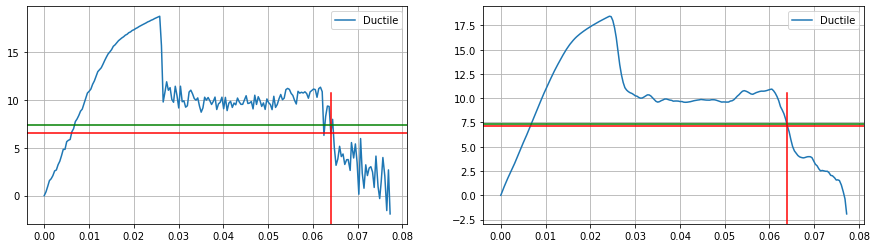

In [10]:
def plt_curve(df_list, typ, label=None):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(15)
    
    for l, df in enumerate(df_list):
        frac = int(df.x.tolist()[0])
        x = df.x.tolist()[1:]
        y = df.y.tolist()[1:]
        y_sm = df.y_sm.tolist()[1:]
        
        if label:
            l = label
        
        ax1.plot(x, y, label=l)
        ax2.plot(x, y_sm, label=l)
        
        if len(df_list) <= 1:
            ax1.axhline(y=y[frac], c='r')
            ax1.axvline(x=x[frac], ymax=0.6, c='r')
            ax1.axhline(y=0.4*max(y_sm), c='g')
            ax2.axhline(y=0.4*max(y_sm), c='g')
            ax2.axhline(y=y_sm[frac], c='r')
            ax2.axvline(x=x[frac], ymax=0.6, c='r')

            if typ.lower() == "ft":
                slope_loc = 0.15*x.index(x[frac])
                slope_idx = int(slope_loc)

                ax1.axvline(x=0.15*x[frac], ymax=0.6, c='g')
                ax2.axvline(x=0.15*x[frac], ymax=0.6, c='g')

                ax2.plot([x[0], x[slope_idx]], [y_sm[0], y_sm[slope_idx]], c='r')
                ax2.plot([x[0], x[slope_idx]], [y[0], y[slope_idx]], c='g')

                slope = np.average([y_sm[i+1]-y_sm[i] for i in range(slope_idx)])/np.average([x[i+1]-x[i] for i in range(slope_idx)])
                ax1.plot([i for i in x[:slope_idx]], [i*slope for i in x[:slope_idx]], c='b')
                ax2.plot([i for i in x[:slope_idx]], [i*slope for i in x[:slope_idx]], c='b')

    ax1.grid()
    ax2.grid()
    ax1.legend()
    ax2.legend()
    plt.show()
    
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plt_curve([UTdf], typ="ut", label="Ductile")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plt_curve([FTdf], typ="ft", label="Fracture")

In [16]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    ductility, strength, stiffness = calcUT(UTdf)
    print(ductility, strength, stiffness)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    P, dd, Ks, Kjs = calcFT(FTdf, geom, E_eff, n_Ks=1, validation=validation, E=E)
    Kic, Kjic = Ks[0], Kjs[0]
    print(P, dd, Kic/(10**6), Kjic/(10**6))

0.0624661215420427 18.44411537667575 1079.4385395602717


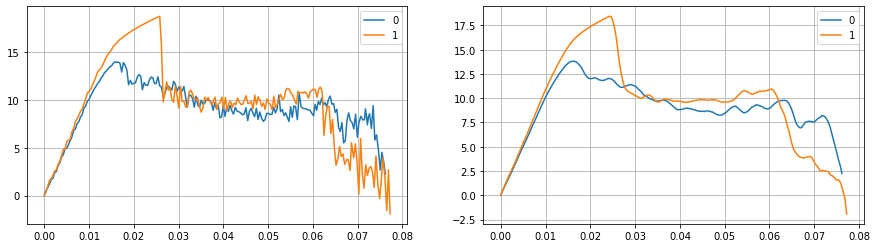

In [17]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    if append:
        UTsave.append([UTdf, ductility, strength, stiffness])
    plt_curve(np.array(UTsave, dtype=object)[:,0], typ="UT")


if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    if append:
        FTsave.append([FTdf, P, dd, Ks, Kjs])
    plt_curve(np.array(FTsave, dtype=object)[:,0], typ="FT")